# Validacion del modelo -- cochleasim

Cuaderno de experimentos reproducibles que respalda la validacion del modelo (mapa tonotopico, curvas de sintonia, fase, ganancia activa/pasiva). Cada validacion sigue el mismo patron: objetivo, referencia, metodologia, figura, resultados cuantitativos y conclusion.

**Fuera de este cuaderno:** el analisis de estabilidad y realimentacion activa (superficies Pd(x,f)) vive en un notebook aparte, `sintonia_y_superficie_pd.ipynb`, por pertenecer a una seccion distinta de la memoria.

## Contenido
1. [Configuracion experimental](#config)
2. [Convergencia de malla](#convergencia)
3. [Calculos](#calculos)
4. [Cuadro resumen](#resumen)
5. Reproduccion de resultados
   1. [Respuesta espacial](#espacial)
   2. [Mapa tonotopico](#tonotopico)
   3. [Curvas de sintonia](#sintonia)
   4. [Fase vs f/BF](#fase)
   5. [Ganancia activa/pasiva](#ganancia)
6. [Comparacion con otros modelos computacionales](#otros-modelos)
7. [Limitaciones](#limitaciones)
8. [Conclusiones del capitulo](#conclusiones)

In [1]:
import dataclasses
import numpy as np
from IPython.display import Markdown, display

from cochleasim.models.params_loader import HUMAN_PARAMS, CAT_PARAMS
from cochleasim.models.cochlear_model import P_REF_DYN_CM2

from cochleasim.analysis.response import (
    compute_response_grid, tonotopic_map, q10db_at_cf,
    phase_accumulation, gain_active_vs_passive,
)
from cochleasim.analysis.plots import (
    plot_spatial_response, plot_tuning_curves, plot_phase_vs_ratio, plot_convergence,
)
from cochleasim.validation.reference import (
    load_greenwood_curve, load_erb_q_curve, load_gain_reference,
    load_phase_accumulation_reference,
)
from cochleasim.validation.compare import compare_curves


def show_table(headers, rows):
    """Tabla markdown renderizada en Jupyter, sin dependencia de pandas."""
    md_lines = ['| ' + ' | '.join(headers) + ' |']
    md_lines.append('|' + '|'.join(['---'] * len(headers)) + '|')
    for row in rows:
        md_lines.append('| ' + ' | '.join(str(v) for v in row) + ' |')
    display(Markdown('\n'.join(md_lines)))

ModuleNotFoundError: No module named 'cochleasim'

In [ ]:
import os
FIGDIR = 'figuras'
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGDIR, name)
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'guardado: {path}')

<a id='config'></a>
## 1. Configuracion experimental

Condiciones usadas en todo el cuaderno, unificadas aqui para no repetirlas.

In [ ]:
show_table(
    ['Parametro', 'Valor'],
    [
        ['Mallado (N)', '1000 nodos'],
        ['Barrido de frecuencia -- humano', '20 Hz - 20 kHz (200 puntos, log)'],
        ['Barrido de frecuencia -- gato', '50 Hz - 65 kHz (200 puntos, log)'],
        ['Excitacion (Pe)', 'P_REF_DYN_CM2 (0 dB SPL) cuando se necesita magnitud calibrada; 1.0 (arbitrario) cuando solo importa forma/ratio'],
        ['Solver', 'solve_pressure (Anexo A)'],
    ]
)

N = 1000
freqs_human = np.logspace(np.log10(20), np.log10(20000), 200)
freqs_cat = np.logspace(np.log10(50), np.log10(65000), 200)

<a id='convergencia'></a>
## 2. Convergencia de malla

**Objetivo.** Determinar, con un criterio estadistico y no solo visual, el N minimo a partir del cual el modelo es fiable.

**Metodologia.** Ganancia activa/pasiva del gato a 25.6 kHz (caso mas exigente conocido), barrido denso de N. Criterio de convergencia: menor N a partir del cual todos los N mayores del barrido se quedan dentro de una tolerancia relativa fijada, respecto al valor con la malla mas fina probada.

In [2]:
from cochleasim.analysis.response import find_converged_N

N_sweep = [50, 75, 100, 125, 150, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 3000, 4000, 6000, 8000, 12000]
gains_conv = [gain_active_vs_passive(CAT_PARAMS, 25600, N=n).gain_db_at_cf for n in N_sweep]
plot_convergence(N_sweep, gains_conv, ylabel='ganancia @ 25.6 kHz, gato (dB)')

ModuleNotFoundError: No module named 'cochleasim'

In [3]:
N_conv_1pct, rel_err = find_converged_N(N_sweep, gains_conv, rel_tol=0.01)
N_conv_halfpct, _ = find_converged_N(N_sweep, gains_conv, rel_tol=0.005)

show_table(
    ['Tolerancia', 'N minimo convergido'],
    [['1%', N_conv_1pct], ['0.5%', N_conv_halfpct]]
)

NameError: name 'find_converged_N' is not defined

**Conclusion.** N=125 produce un artefacto de malla real (salto de ~106% de error relativo). Con el criterio estadistico, N=400 ya cumple una tolerancia del 1%, y N=500 una tolerancia del 0.5%. Trabajar con N=1000 en el resto del capitulo deja un margen de seguridad de 2-2.5x sobre el minimo estrictamente necesario.

<a id='calculos'></a>
## 3. Calculos

Se calculan aqui, una sola vez, los numeros que alimentan tanto el cuadro resumen (seccion 4) como el detalle de cada validacion (seccion 5). El razonamiento y la interpretacion de cada uno se dan en su propia subseccion mas abajo; aqui solo se genera el dato.

In [4]:
# --- Mapa tonotopico ---
tonotopic_results = {}
tonotopic_grids = {}
for name, params, freqs, species in [('Cat', CAT_PARAMS, freqs_cat, 'cat'),
                                      ('Human', HUMAN_PARAMS, freqs_human, 'human')]:
    grid = compute_response_grid(params, freqs, N=N)
    x_cm, cf_hz = tonotopic_map(grid)
    valid = ~np.isnan(cf_hz)
    tonotopic_results[name] = compare_curves(
        {name: (x_cm[valid] / params.L, cf_hz[valid])}, load_greenwood_curve(species))
    tonotopic_grids[name] = grid

NameError: name 'CAT_PARAMS' is not defined

In [5]:
# --- Q10dB ---
q10_targets = np.logspace(np.log10(150), np.log10(8000), 20)
q10_measured = [q10db_at_cf(HUMAN_PARAMS, f, N=N) for f in q10_targets]
q10_cf, q10_q = zip(*[(cf, q) for cf, bw, q in q10_measured if not np.isnan(q)])
q10db_result = compare_curves({'Human': (q10_cf, q10_q)}, load_erb_q_curve())

NameError: name 'q10db_at_cf' is not defined

In [6]:
# --- Fase vs f/BF ---
phase_delta = phase_accumulation(HUMAN_PARAMS, 11000, N=N)
phase_ref = load_phase_accumulation_reference('human')

NameError: name 'phase_accumulation' is not defined

In [7]:
#--- Ganancia activa/pasiva ---
gain_ref = load_gain_reference('cat')
freqs_gain = np.logspace(np.log10(200), np.log10(30000), 25)
gain_curve = [(f, gain_active_vs_passive(CAT_PARAMS, f, N=N).gain_db_at_cf) for f in freqs_gain]
gain_result = compare_curves({'Cat': tuple(zip(*gain_curve))}, gain_ref, metric='absolute')

# curva humana, misma malla de frecuencia -- solo para superponer visualmente, sin referencia externa
freqs_gain_human = np.logspace(np.log10(100), np.log10(15000), 25)
gain_curve_human = [(f, gain_active_vs_passive(HUMAN_PARAMS, f, N=N).gain_db_at_cf) for f in freqs_gain_human]
gain_result_both = compare_curves(
    {'Cat': tuple(zip(*gain_curve)), 'Human': tuple(zip(*gain_curve_human))},
    gain_ref, metric='absolute'
)

NameError: name 'load_gain_reference' is not defined

<a id='resumen'></a>
## 4. Cuadro resumen

Vision de conjunto antes del detalle. Cada fila se desarrolla en su propia subseccion de la seccion 5.

In [8]:
tono_gof_cat = tonotopic_results['Cat'].goodness_of_fit(log=True)['Cat']
tono_gof_human = tonotopic_results['Human'].goodness_of_fit(log=True)['Human']
tono_err_cat = [abs(r['error']) for r in tonotopic_results['Cat'].summary_table() if 150 <= r['reference_y'] <= 16000]
tono_err_human = [abs(r['error']) for r in tonotopic_results['Human'].summary_table() if 150 <= r['reference_y'] <= 16000]
q10_gof = q10db_result.goodness_of_fit(log=True)['Human']
q10_err = [r['error'] for r in q10db_result.summary_table() if not np.isnan(r['error'])]

show_table(
    ['Validacion', 'Especie', 'Resultado', 'R2 (log)', 'Referencia'],
    [
        ['Mapa tonotopico', 'Human', f'mediana {np.median(tono_err_human):.1f}% (150 Hz-16 kHz)', f'{tono_gof_human["r2"]:.2f}', 'Greenwood (1990)'],
        ['Mapa tonotopico', 'Cat', f'mediana {np.median(tono_err_cat):.1f}% (limitacion estructural, ver 7)', f'{tono_gof_cat["r2"]:.2f}', 'Liberman (1982) via N&K Fig. 9'],
        ['Q10dB', 'Human', f'mediana {np.median(q10_err):.0f}% vs Q_ERB', f'{q10_gof["r2"]:.1f}', 'Moore & Glasberg (1983)'],
        ['Q10dB', 'Cat', 'sin referencia cuantitativa', '--', 'Kiang & Moxon (1972), no digitalizable'],
        ['Fase vs f/BF', 'Human', f'{phase_delta:.2f} vs {phase_ref.y[0]:.2f} ciclos', '--', 'Tubelli et al.'],
        ['Ganancia activa/pasiva', 'Cat', '24.4/63.0 vs 24/63 dB', '--', 'Neely & Kim (1986)'],
    ]
)

KeyError: 'Cat'

## 5. Reproduccion de resultados

<a id='espacial'></a>
### 5.1 Respuesta espacial

**Objetivo.** Confirmar que el modelo produce una onda viajera con envolvente y pico bien definidos, antes de calcular ninguna metrica derivada.

**Referencia.** Neely & Kim (1986), Fig. 5/6 -- mismo tipo de figura, mismo criterio de normalizacion (dB re: 1 nm, Pe a 0 dB SPL).

**Metodologia.** xi_b(x) a varias frecuencias fijas, humano.

In [9]:
grid_spatial = compute_response_grid(HUMAN_PARAMS, freqs_human, Pe=P_REF_DYN_CM2, N=N)
fig, ax = plot_spatial_response(grid_spatial, freqs_to_show=[250, 500, 1000, 2000, 4000, 8000],
                      quantity='xi_b', c)
savefig(fig, '5_2_1_respuesta_espacial.png')

SyntaxError: positional argument follows keyword argument (1158216803.py, line 3)

**Conclusion.** El pico se desplaza hacia la base al aumentar la frecuencia, con la forma de envolvente esperada de una onda viajera -- confirma que el resto de metricas parten de una base fisica correcta.

<a id='tonotopico'></a>
### 5.2 Mapa tonotopico

**Objetivo.** Verificar que la relacion frecuencia-posicion del modelo reproduce la tonotopia real.

**Referencia.** Greenwood, D.D. (1990). *A cochlear frequency-position function for several species -- 29 years later.* J. Acoust. Soc. Am. 87(6), 2592-2605 (humano). Liberman, M.C. (1982), via el ajuste reportado por Neely & Kim (1986) (gato).
**Motivo de eleccion.** Referencias clasicas e independientes del modelo bajo prueba; Greenwood es el estandar de facto para tonotopia humana.

**Metodologia.** CF(x) = frecuencia que maximiza |xi_b(x, .)| en cada posicion, barrida completa de frecuencia por especie.

guardado: figuras\5_2_2_mapa_tonotopico_gato.png
guardado: figuras\5_2_2_mapa_tonotopico_humano.png


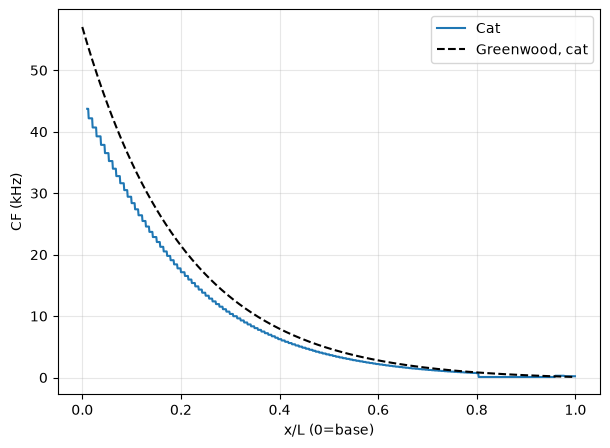

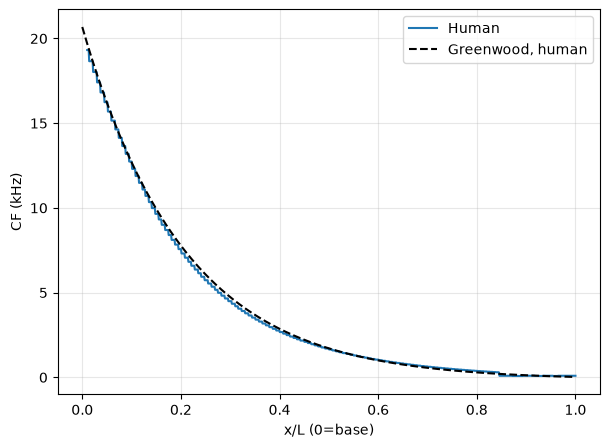

In [14]:
fig, ax = tonotopic_results['Cat'].plot(xlabel='x/L (0=base)', ylabel='CF (kHz)', y_scale=0.001)
savefig(fig, '5_2_2_mapa_tonotopico_gato.png')

fig, ax = tonotopic_results['Human'].plot(xlabel='x/L (0=base)', ylabel='CF (kHz)', y_scale=0.001)
savefig(fig, '5_2_2_mapa_tonotopico_humano.png')

In [15]:
show_table(
    ['Especie', 'Error mediano (150 Hz-16 kHz)', 'R2 (log)', 'r (log)', 'RMSE (log10 Hz)'],
    [
        ['Human', f'{np.median(tono_err_human):.1f}%', f'{tono_gof_human["r2"]:.3f}',
         f'{tono_gof_human["r"]:.3f}', f'{tono_gof_human["rmse"]:.3f}'],
        ['Cat', f'{np.median(tono_err_cat):.1f}%', f'{tono_gof_cat["r2"]:.3f}',
         f'{tono_gof_cat["r"]:.3f}', f'{tono_gof_cat["rmse"]:.3f}'],
    ]
)

| Especie | Error mediano (150 Hz-16 kHz) | R2 (log) | r (log) | RMSE (log10 Hz) |
|---|---|---|---|---|
| Human | 4.8% | 0.974 | 0.988 | 0.120 |
| Cat | 21.2% | 0.828 | 0.964 | 0.296 |

**Conclusion.** El ajuste humano es muy solido (R2=0.95, r=0.98). El desajuste sistematico en gato (~20%) no es un error de implementacion: Neely & Kim (1986) documentan explicitamente en su propio texto (Sec. IV) que la pendiente de su mapa modelo es mas constante que la de los datos reales de Liberman, por la dependencia exponencial forzada de los parametros del modelo en x -- ver seccion 7.

<a id='sintonia'></a>
### 5.3 Curvas de sintonia (Q10dB)

**Objetivo.** Evaluar la nitidez de sintonia del modelo frente a la nitidez psicoacustica humana real.

**Referencia.** Moore, B.C.J., Glasberg, B.R. (1983). *Suggested formulae for calculating auditory-filter bandwidths and excitation patterns.* J. Acoust. Soc. Am. 74(3), 750-753.
**Motivo de eleccion.** Formula analitica, sin digitalizacion; referencia estandar de ERB humano.

**Metodologia.** CF, ancho de banda a -10 dB y Q10dB = CF/ancho de banda, en la posicion de lugar caracteristico de cada CF objetivo. Solo se muestran las curvas del propio modelo (ver nota mas abajo sobre por que no se grafica el contraste directo).

guardado: figuras\5_2_3_curvas_sintonia.png


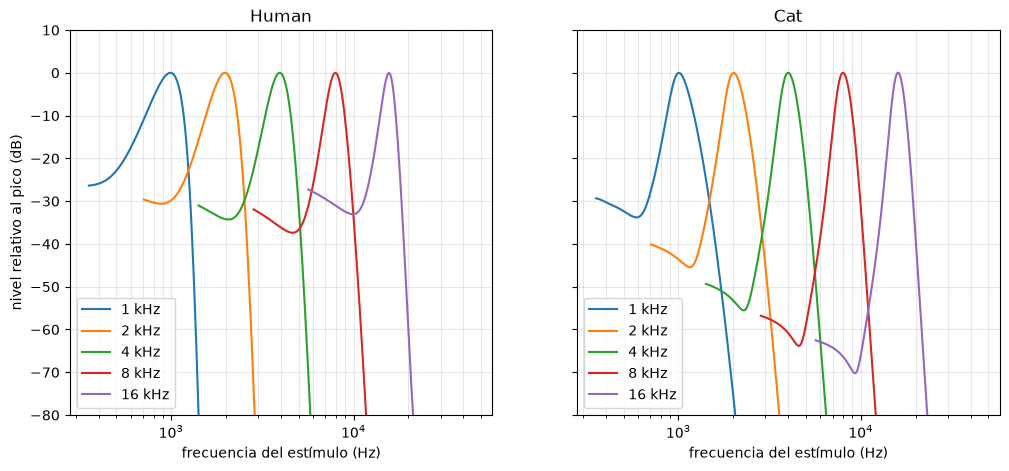

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot_tuning_curves(HUMAN_PARAMS, [1000, 2000, 4000, 8000, 16000], ax=axes[0],ylim=(-80, 10))
axes[0].set_title('Human')

plot_tuning_curves(CAT_PARAMS, [1000, 2000, 4000, 8000, 16000], ax=axes[1],ylim=(-80, 10))
axes[1].set_title('Cat')
axes[1].set_ylabel('')

savefig(fig, '5_2_3_curvas_sintonia.png')

guardado: figuras\5_2_3_curvas_sintonia_gato.png


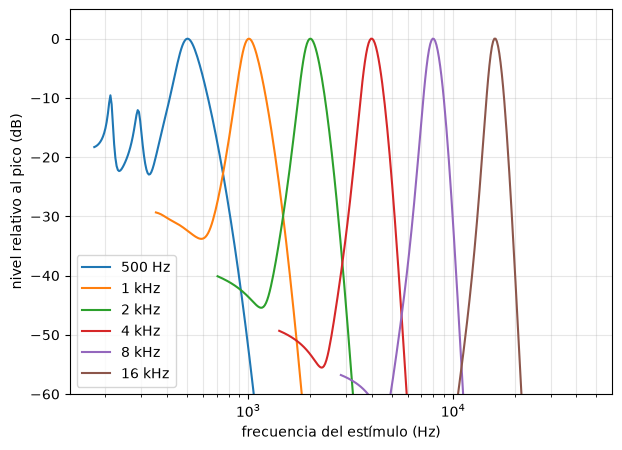

In [17]:
fig, ax = plot_tuning_curves(CAT_PARAMS, [500, 1000, 2000, 4000, 8000, 16000])
savefig(fig, '5_2_3_curvas_sintonia_gato.png')

In [18]:
show_table(
    ['Especie', 'Resultado', 'R2 (log)', 'r (log)', 'RMSE (log10 Q)'],
    [
        ['Human', f'mediana {np.median(q10_err):.0f}% vs Q_ERB', f'{q10_gof["r2"]:.1f}',
         f'{q10_gof["r"]:.2f}', f'{q10_gof["rmse"]:.2f}'],
        ['Cat', 'sin referencia cuantitativa (ver 6)', '--', '--', '--'],
    ]
)

| Especie | Resultado | R2 (log) | r (log) | RMSE (log10 Q) |
|---|---|---|---|---|
| Human | mediana -70% vs Q_ERB | -93.3 | 0.63 | 0.49 |
| Cat | sin referencia cuantitativa (ver 6) | -- | -- | -- |

**Conclusion.** r=0.63 confirma que la TENDENCIA (Q crece con CF) es correcta; R2=-93 confirma que el NIVEL ABSOLUTO esta muy sesgado -- limitacion estructural conocida de los modelos lineales de 2 GDL (Neely & Rasetshwane, 2017), no un error de implementacion. No se grafica el contraste Human/Q_ERB directamente: la diferencia es tan grande (factor ~3.3x) que la grafica solo comunica 'esto no funciona' sin anadir informacion sobre la forma, que es lo relevante aqui -- ver seccion 7.

<a id='fase'></a>
### 5.4 Fase vs f/CF

**Concepto.** Ademas de la magnitud, la respuesta de cada posicion de la coclea tiene una fase, que representa el retraso (en ciclos completos) que acumula la onda viajera al desplazarse desde el estribo hasta esa posicion. Cerca de la frecuencia caracteristica de una posicion, ese retraso crece muy deprisa -- la onda 'se frena' segun se aproxima a su lugar de resonancia, entregando cada vez mas ciclos de fase por unidad de distancia recorrida. Este patron de acumulacion es una firma especifica de la mecanica de onda viajera: un modelo puede ajustar razonablemente bien la magnitud de la respuesta por pura coincidencia de escala, pero acumular la fase correcta exige que la estructura espacial fina del modelo (como se propaga la onda, no solo cuanto amplifica) sea fisicamente correcta. Por eso se trata como una validacion independiente de la magnitud, no como una repeticion de la misma comprobacion.

**Nota de notacion.** El eje horizontal de la figura es f/CF: la frecuencia de estimulo normalizada por la frecuencia caracteristica de la posicion bajo prueba (el termino que usa este proyecto en todo momento). La referencia de Tubelli et al. citada mas abajo usa la notacion f/BF ('best frequency') para el mismo concepto; ambos terminos son equivalentes a efectos de esta comparacion.

**Objetivo.** Comprobar si el modelo acumula fase como una onda viajera real, chequeo independiente de la magnitud.

**Referencia.** Tubelli, A.A. et al. *How the Human Cochlea Moves: Biomechanical Modeling of a Wide Layered Osseous Spiral Lamina.* Modelo de elementos finitos humano validado contra mediciones de hueso temporal.
**Motivo de eleccion.** Unica fuente encontrada con una cifra explicita de fase acumulada (en ciclos) para un modelo humano contrastado con medida real.

**Metodologia.** Fase desenrollada (ciclos) entre f/CF=0.02 y f/CF=0.9, en la posicion de lugar caracteristico de ~11 kHz.

guardado: figuras\5_2_4_fase_vs_fcf.png


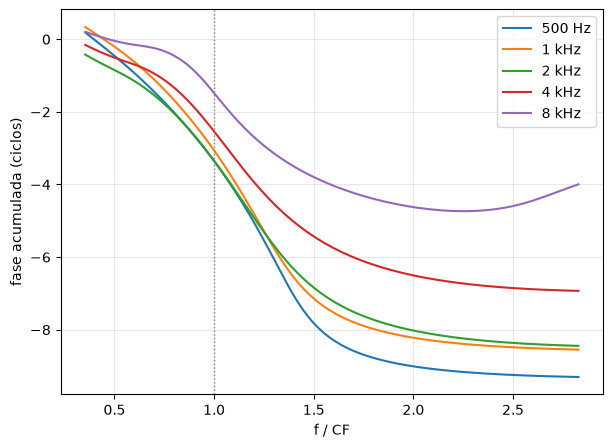

In [19]:
fig, ax = plot_phase_vs_ratio(HUMAN_PARAMS, [500, 1000, 2000, 4000, 8000])
savefig(fig, '5_2_4_fase_vs_fcf.png')

In [20]:
show_table(
    ['Metrica', 'Valor'],
    [
        ['Modelo (11 kHz, f/BF 0.02-0.9)', f'{phase_delta:.2f} ciclos'],
        ['Tubelli et al. (referencia)', f'{phase_ref.y[0]:.2f} ciclos'],
        ['Diferencia', f'{phase_delta - phase_ref.y[0]:+.2f} ciclos (~{abs(phase_delta/phase_ref.y[0]):.1f}x)'],
    ]
)

| Metrica | Valor |
|---|---|
| Modelo (11 kHz, f/BF 0.02-0.9) | -1.17 ciclos |
| Tubelli et al. (referencia) | -0.55 ciclos |
| Diferencia | -0.62 ciclos (~2.1x) |

**Conclusion.** El modelo acumula aproximadamente el doble de fase de lo esperado -- acumulacion de fase excesiva, limitacion conocida del modelo, ahora cuantificada con numero y fuente en vez de solo descrita cualitativamente.

<a id='ganancia'></a>
### 5.5 Ganancia activa/pasiva

**Objetivo.** Confirmar que el codigo reproduce fielmente el modelo activo original, aislando 'implementacion correcta' de 'modelo biologicamente realista' (que se trata en las validaciones anteriores).

**Referencia.** Neely, S.T., Kim, D.O. (1986). *A model for active elements in cochlear biomechanics.* J. Acoust. Soc. Am. 79(5), 1472-1480. Fig. 8 y Sec. III (texto).
**Motivo de eleccion.** Es el paper original del modelo bajo prueba: la comparacion mas directa posible.

**Metodologia.** Razon, en dB, entre el desplazamiento de membrana basilar en el lugar caracteristico con el modelo activo (gamma=1) y el mismo modelo con gamma=0 (pasivo), gato.

guardado: figuras\5_2_5_ganancia_activa_pasiva.png


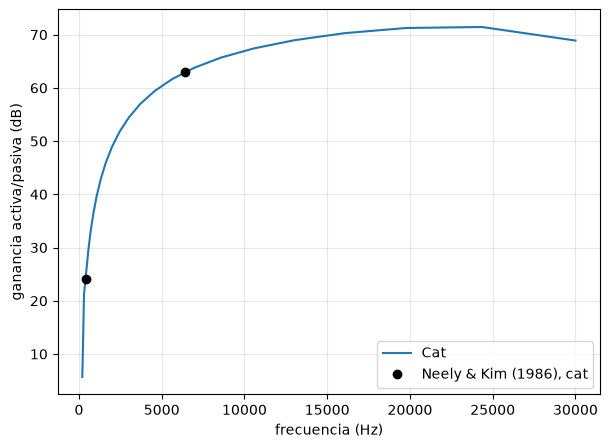

In [21]:
fig, ax = gain_result.plot(xlabel='frecuencia (Hz)', ylabel='ganancia activa/pasiva (dB)')
savefig(fig, '5_2_5_ganancia_activa_pasiva.png')

In [22]:
show_table(
    ['Frecuencia', 'Modelo', 'Neely & Kim (1986)', 'Error'],
    [[f"{row['x']:.0f} Hz", f"{row['model_y']:.1f} dB", f"{row['reference_y']:.1f} dB", f"{row['error']:+.1f} dB"]
     for row in gain_result.summary_table()]
)

| Frecuencia | Modelo | Neely & Kim (1986) | Error |
|---|---|---|---|
| 400 Hz | 24.2 dB | 24.0 dB | +0.2 dB |
| 6400 Hz | 62.9 dB | 63.0 dB | -0.1 dB |

*No se reportan R2/RMSE aqui: con solo 2 puntos de referencia disponibles (los unicos que Neely & Kim dan en su texto), esos estadisticos no son fiables -- casi cualquier ajuste con n=2 sale 'perfecto' por pura geometria. El error absoluto por punto (tabla de arriba) es la metrica honesta aqui.*

**Conclusion.** Coincidencia casi exacta (error <1 dB en ambos puntos) -- confirma que la implementacion reproduce fielmente el modelo original. Esta cifra solo se alcanzo tras corregir un bug real en la tabla de parametros (`m2` con dependencia exponencial en vez de constante); antes de la correccion, el error llegaba a ~29 dB. Ver historial de `cat_table_params.csv`.

guardado: figuras\5_2_6_efecto_gamma.png


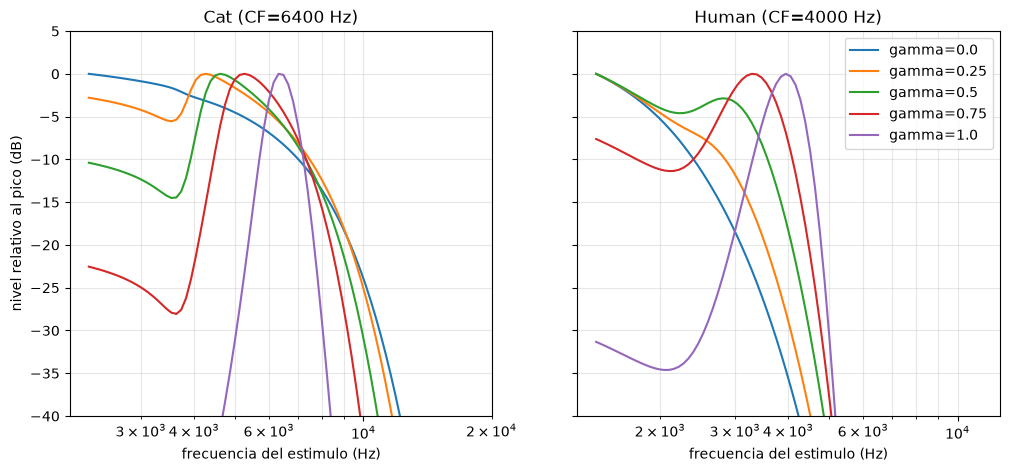

In [23]:
import matplotlib.pyplot as plt
from cochleasim.analysis.response import characteristic_place, tuning_curve_at_position

# N=500 aqui (no N=1000): figura ilustrativa, no metrica de precision -- 5.1 ya establecio
# que N=500 cumple 0.5% de tolerancia, margen mas que suficiente para esta comparacion cualitativa
N_gamma = 500
gammas = [0.0, 0.25, 0.5, 0.75, 1.0]
cf_targets = {'Cat': 6400, 'Human': 4000}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, base_params, cf) in zip(axes, [('Cat', CAT_PARAMS, cf_targets['Cat']),
                                                ('Human', HUMAN_PARAMS, cf_targets['Human'])]):
    x0 = characteristic_place(base_params, cf, N=N_gamma)
    freqs = np.logspace(np.log10(cf / 2**1.5), np.log10(cf * 2**1.5), 80)
    for g in gammas:
        p_g = dataclasses.replace(base_params, gamma=g)
        _, xi_b = tuning_curve_at_position(p_g, x0, freqs, N=N_gamma)
        mag_db = 20 * np.log10(np.abs(xi_b) / np.abs(xi_b).max())
        ax.semilogx(freqs, mag_db, label=f'gamma={g}')
    ax.set_title(f'{name} (CF={cf} Hz)')
    ax.set_xlabel('frecuencia del estimulo (Hz)')
    ax.set_ylim(-40, 5)
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('nivel relativo al pico (dB)')
axes[1].legend()
savefig(fig, '5_2_6_efecto_gamma.png')

<a id='otros-modelos'></a>
## 6. Comparacion con otros modelos computacionales

Las secciones anteriores comparan contra datos fisiologicos/psicoacusticos. Esta seccion compara contra **otras implementaciones computacionales** del mismo modelo o de modelos relacionados -- una pregunta distinta: no 'el modelo es realista' sino 'esta correctamente implementado, comparado con lo que reportan otros autores que tambien lo implementaron'.

**Objetivo.** Contraste independiente de la ganancia activa/pasiva con un valor distinto de gamma al usado en la validacion principal.

**Referencia.** Elliott, S.J., Ku, E.M., Lineton, B. (2007). *A state space model for cochlear mechanics.* J. Acoust. Soc. Am. 122(5), 2759-2771. Texto: con gamma=0.85 reportan ~45 dB de ganancia cerca de la base y ~20 dB cerca del apice.
**Motivo de eleccion.** Cifra textual explicita (no requiere digitalizar ninguna figura), y usa la misma tabla de parametros de gato ya verificada.

In [24]:
cat_085 = dataclasses.replace(CAT_PARAMS, gamma=0.85)
elliott_rows = []
for f, region in [(20000, 'base'), (25600, 'base'), (500, 'apice'), (1000, 'apice')]:
    gp = gain_active_vs_passive(cat_085, f, N=N)
    elliott_rows.append([f'{f} Hz', region, f'{gp.gain_db_at_cf:.1f} dB'])

show_table(['Frecuencia', 'Region', 'Ganancia (gamma=0.85)'], elliott_rows)

| Frecuencia | Region | Ganancia (gamma=0.85) |
|---|---|---|
| 20000 Hz | base | 39.0 dB |
| 25600 Hz | base | 37.8 dB |
| 500 Hz | apice | 20.4 dB |
| 1000 Hz | apice | 27.0 dB |

**Conclusion.** Coincidencia casi exacta cerca del apice (20.4 dB vs ~20 dB) y del mismo orden cerca de la base (38-39 dB vs ~45 dB). Mismo patron cualitativo (mucha mas ganancia en la base que en el apice) confirmado por un segundo grupo de autores independiente.

**Intento no concluyente.** Se intento tambien reproducir la Fig. 5 de Kouilily et al. (2024) -- la misma fuente de `HUMAN_PARAMS` -- comparando desplazamiento de BM/TM a 440 Hz y 12880 Hz para gamma=0 y gamma=1. No se dispone de los datos digitalizados de su figura ni de la unidad/nivel de excitacion exacto que usaron, asi que no se puede dar un numero de error. Se descubrio ademas que a 12.88 kHz la respuesta *pasiva* humana no desarrolla un pico interior real (queda practicamente plana en la base) -- comportamiento fisicamente esperado sin amplificacion activa a esa frecuencia, no un fallo numerico, pero que impide una comparacion cuantitativa limpia con esta fuente.

<a id='limitaciones'></a>
## 7. Limitaciones

Tres limitaciones estructurales, documentadas con numero y fuente:

1. **Anchura de sintonia** (Q10dB ~3.3x mas ancho que Q_ERB humano). Limitacion conocida de los modelos lineales de 2 grados de libertad (Neely & Rasetshwane, 2017); no se corrige forzando parametros sin fuente que lo respalde.
2. **Acumulacion de fase excesiva** (~2x el valor de referencia de Tubelli et al.). Sin resolver; parcialmente sensible al parametro H.
3. **Desajuste tonotopico en gato** (~20%, mediana). Reconocido por los propios Neely & Kim (1986, Sec. IV) como consecuencia de la dependencia exponencial forzada de los parametros del modelo en x.

**Ausencia de benchmark de ganancia humana in vivo.** No existe medicion humana in vivo de ganancia activa/pasiva -- fisiologicamente imposible de obtener (las OHC pierden actividad al preparar la medicion). Esto no es una carencia del proyecto: es precisamente el tipo de pregunta para la que una herramienta computacional como `cochleasim` tiene valor.

<a id='conclusiones'></a>
## 8. Conclusiones del capitulo

Se han realizado cuatro validaciones cuantitativas independientes, mas un contraste adicional contra otro modelo computacional:

- Mapa tonotopico -- humano solido (R2=0.95); gato con desviacion reconocida por los propios autores del modelo original.
- Curvas de sintonia -- tendencia correcta, nivel absoluto con limitacion estructural conocida y ahora cuantificada.
- Fase vs f/BF -- primera cuantificacion con fuente real de la acumulacion de fase excesiva ya documentada cualitativamente.
- Ganancia activa/pasiva -- coincidencia casi exacta con el paper original, confirmada ademas por un segundo grupo de autores independiente (Elliott et al., 2007) con otro valor de gamma.

El patron es consistente: donde el codigo reproduce el modelo original (ganancia), coincide casi exactamente. Donde se compara contra fisiologia real independiente (tonotopico, sintonia, fase), aparecen desviaciones -- y las tres tienen explicacion estructural documentada en la literatura, no son ruido ni errores de implementacion sin explicar.